In [1]:
import joblib
from collections import Counter
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from benchmark.calibration import brier_score, expected_calibration_error
from benchmark.checkpoints import available_models, ckpt_path
from benchmark.plots import ACCENT, CONTEXT, INK, critical_difference_diagram, style_axes
from benchmark.stats import average_ranks, cliques, friedman_p, wilcoxon_holm

sns.set(context='poster')

In [2]:
svc_results, log_reg_results, random_forest_results, evaluated_datasets, baseline_times = joblib.load('results/compare_baseline_models.joblib')

database = pd.read_json('database.json').T
database.loc[:, 'nrow'] = np.minimum(10000, database['nrow'])

# AutoML covers 142 of 146 datasets, so rows must be joined by name: a
# positional slice assumes the missing four are last, and they are not.
autogluon_results, autogluon_times, automl_datasets = joblib.load('results/autogluon_sec_300.joblib')
mljar_results, mljar_times, mljar_datasets = joblib.load('results/mljar_sec_300.joblib')
assert list(mljar_datasets) == list(automl_datasets), 'AutoML runs cover different datasets'

optuna_results, optuna_times, optuna_datasets = joblib.load('results/optuna_models.joblib')


In [3]:
FOLD_COLS = ['prauc_fold_1', 'prauc_fold_2', 'prauc_fold_3', 'prauc_fold_4']

svc_df = pd.DataFrame(svc_results, columns=FOLD_COLS, index=evaluated_datasets)
svc_df['model'] = 'SVC'
log_reg_df = pd.DataFrame(log_reg_results, columns=FOLD_COLS, index=evaluated_datasets)
log_reg_df['model'] = 'Logistic Regression'
random_forest_df = pd.DataFrame(random_forest_results, columns=FOLD_COLS, index=evaluated_datasets)
random_forest_df['model'] = 'Random Forest'

autogluon_df = pd.DataFrame(autogluon_results, columns=FOLD_COLS, index=automl_datasets)
autogluon_df['model'] = 'AutoGluon (sec=300)'
mljar_df = pd.DataFrame(mljar_results, columns=FOLD_COLS, index=automl_datasets)
mljar_df['model'] = 'MLJAR (sec=300)'

OPTUNA_MODEL_LABELS = {
    'svc':            'SVC (GridSearch)',
    'logreg':         'Logistic Regression (GridSearch)',
    'random_forest':  'Random Forest (Optuna)',
    'xgboost':        'XGBoost (Optuna)',
    'sgd':            'SGD (Optuna)',
    'catboost':       'CatBoost (Optuna)',
    'lgbm':           'LightGBM (Optuna)',
    'lgbm_linear':    'LightGBM Linear (Optuna)',
    'hgb':            'HistGradientBoosting (Optuna)',
    'resnet':         'ResNet (Optuna)',
    'tabnet':         'TabNet (Optuna)',
    'tabpfn':         'TabPFN 2.6 (GridSearch)',
    'tabpfn3':        'TabPFN-3 (GridSearch)',
    'tabicl':         'TabICL (GridSearch)',
    'tabfm':          'TabFM (zero-shot)',
}
missing = [k for k in OPTUNA_MODEL_LABELS if k not in optuna_results]
if missing:
    print(f'WARNING: absent from the aggregate, not plotted: {missing}')

optuna_dfs = []
for model_key, label in OPTUNA_MODEL_LABELS.items():
    if model_key not in optuna_results:
        continue
    df = pd.DataFrame(optuna_results[model_key], columns=FOLD_COLS, index=optuna_datasets)
    df['model'] = label
    optuna_dfs.append(df)

In [4]:
SPLIT_COLS = ['prauc_split_1', 'prauc_split_2', 'prauc_split_3', 'prauc_split_4']

results_df = pd.concat(
    [svc_df, log_reg_df, random_forest_df,
     autogluon_df, mljar_df]
    + optuna_dfs,
    axis=0
)
results_df.columns = SPLIT_COLS + ['model']
results_df['dataset'] = results_df.index

# map, not join: the index repeats once per model per dataset.
for col in database.columns:
    results_df[col] = results_df.index.map(database[col]).to_numpy()

results_df['mean_prauc'] = results_df[SPLIT_COLS].mean(axis=1)
results_df['min_prauc']  = results_df[SPLIT_COLS].min(axis=1)
results_df['max_prauc']  = results_df[SPLIT_COLS].max(axis=1)
results_df['std_prauc']  = results_df[SPLIT_COLS].std(axis=1)

# Per-fold delta relative to RF baseline (compare_baseline_models GridSearch RF)
rf_baseline = pd.DataFrame(
    random_forest_results,
    columns=SPLIT_COLS,
    index=evaluated_datasets,
)
RF_COLS    = ['rf_prauc_split_1', 'rf_prauc_split_2', 'rf_prauc_split_3', 'rf_prauc_split_4']
DELTA_COLS = ['delta_split_1', 'delta_split_2', 'delta_split_3', 'delta_split_4']
for rf_col, split_col in zip(RF_COLS, SPLIT_COLS):
    results_df[rf_col] = results_df.index.map(rf_baseline[split_col]).to_numpy()
for delta_col, split_col, rf_col in zip(DELTA_COLS, SPLIT_COLS, RF_COLS):
    results_df[delta_col] = results_df[split_col] - results_df[rf_col]

results_df['mean_delta'] = results_df[DELTA_COLS].mean(axis=1)
results_df['std_delta']  = results_df[DELTA_COLS].std(axis=1)

# Integer index: duplicate dataset labels break seaborn's internals.
results_df = results_df.reset_index(drop=True)


In [5]:
# Drop datasets where every algorithm already does really well.
results_df = results_df.groupby('dataset').filter(lambda x: x['mean_prauc'].min() < 0.99)

In [6]:
# Drop UCI++ variants that score identically across the board.
duped_datasets = [
    'wine-quality-white-5class', 'waveform-v2',
    'volcanoes-a3', 'volcanoes-b3', 'volcanoes-b4',
    'volcanoes-b5', 'volcanoes-b6', 'volcanoes-d3', 'volcanoes-d4',
    'statlog-german-credit-numeric', 'thyroid-allhyper', 'thyroid-allhypo',
    'thyroid-allrep', 'thyroid-hypothyroid', 'thyroid-dis'
]
results_df = results_df[~results_df['dataset'].isin(duped_datasets)].reset_index(drop=True)
evaluated_datasets = set(results_df['dataset'])


In [7]:
winning_algorithms = []
for dataset in evaluated_datasets:
    df_sub = results_df[results_df['dataset'] == dataset]
    highest_prauc = df_sub['mean_prauc'].max()
    winning_algorithms.extend(df_sub.loc[df_sub['mean_prauc'] >= highest_prauc * 0.995, 'model'])
print('Datasets each algorithm does best on (a model unscored on a dataset can '
      'never win it — read with the coverage column below):')
pprint(Counter(winning_algorithms))

losing_algorithms = []
for dataset in evaluated_datasets:
    df_sub = results_df[results_df['dataset'] == dataset]
    worst_prauc = df_sub['mean_prauc'].min()
    losing_algorithms.extend(df_sub.loc[df_sub['mean_prauc'] <= worst_prauc * 1.005, 'model'])
print('\nDatasets each algorithm does worst on:')
pprint(Counter(losing_algorithms))

# Coverage differs by model and pandas skips NaN, so each model is averaged
# over its own subset. n makes that visible.
print('\nDelta PR AUC vs RF baseline, each model over its own coverage:')
print(results_df.groupby('model')['mean_delta']
      .agg(n='count', mean='mean', median='median')
      .sort_values('mean', ascending=False).to_string())

# Paired view over identical datasets. Models below MIN_COVERAGE are dropped
# rather than allowed to shrink the intersection.
MIN_COVERAGE = 0.9
pivot_delta = results_df.pivot_table(index='dataset', columns='model', values='mean_delta')
paired_models = pivot_delta.columns[pivot_delta.notna().mean() >= MIN_COVERAGE]
paired = pivot_delta[paired_models].dropna()
print(f'\nComplete-case delta vs RF ({len(paired)} datasets, {len(paired_models)} '
      f'models at >={MIN_COVERAGE:.0%} coverage):')
print(paired.mean().sort_values(ascending=False).to_string())

# Pairwise win/loss matrix
models_ordered = results_df.groupby('model')['mean_delta'].mean().sort_values(ascending=False).index.tolist()
pivot = results_df.pivot_table(index='dataset', columns='model', values='mean_prauc')
TOL = 0.005
win_matrix = pd.DataFrame(index=models_ordered, columns=models_ordered, dtype=float)
for a in models_ordered:
    for b in models_ordered:
        if a == b:
            win_matrix.loc[a, b] = np.nan
        else:
            diff = pivot[a] - pivot[b]
            win_matrix.loc[a, b] = (diff.dropna() > TOL).sum()
print('\nPairwise wins (row beats col on N datasets, each pair on its own overlap):')
print(win_matrix.to_string())

# Complete cases and method='min': fractional ranks from method='average' match
# no integer column and drop out of the distribution silently.
rank_pivot = pivot[paired_models].dropna().rank(axis=1, ascending=False, method='min')
rank_dist = pd.DataFrame(index=paired_models)
for r in range(1, len(paired_models) + 1):
    rank_dist[f'rank_{r}'] = (rank_pivot == r).sum()
rank_dist['mean_rank'] = rank_pivot.mean()
print(f'\nRank distribution over {len(rank_pivot)} complete-case datasets:')
print(rank_dist.sort_values('mean_rank').to_string())

Datasets each algorithm does best on (a model unscored on a dataset can never win it — read with the coverage column below):
Counter({'MLJAR (sec=300)': 72,
         'AutoGluon (sec=300)': 64,
         'TabPFN-3 (GridSearch)': 55,
         'TabICL (GridSearch)': 55,
         'TabFM (zero-shot)': 48,
         'CatBoost (Optuna)': 38,
         'TabPFN 2.6 (GridSearch)': 35,
         'Random Forest': 34,
         'Random Forest (Optuna)': 31,
         'XGBoost (Optuna)': 31,
         'LightGBM (Optuna)': 31,
         'SVC (GridSearch)': 30,
         'LightGBM Linear (Optuna)': 30,
         'HistGradientBoosting (Optuna)': 28,
         'ResNet (Optuna)': 27,
         'SVC': 25,
         'Logistic Regression': 23,
         'Logistic Regression (GridSearch)': 17,
         'TabNet (Optuna)': 16,
         'SGD (Optuna)': 10})

Datasets each algorithm does worst on:
Counter({'TabNet (Optuna)': 58,
         'SGD (Optuna)': 21,
         'TabPFN 2.6 (GridSearch)': 19,
         'Logistic Regression

In [8]:
flag = set(database[database.nrow < 250].index)

print('Average delta vs RF baseline when nrow < 250')
print(results_df[results_df['dataset'].isin(flag)].groupby('model')['mean_delta'].mean().sort_values(ascending=False))
print('\nMedian delta vs RF baseline when nrow < 250')
print(results_df[results_df['dataset'].isin(flag)].groupby('model')['mean_delta'].median().sort_values(ascending=False))


Average delta vs RF baseline when nrow < 250
model
AutoGluon (sec=300)                 0.034126
TabICL (GridSearch)                 0.033152
TabFM (zero-shot)                   0.030974
MLJAR (sec=300)                     0.030939
TabPFN-3 (GridSearch)               0.028513
CatBoost (Optuna)                   0.013776
Random Forest (Optuna)              0.008966
TabPFN 2.6 (GridSearch)             0.004247
SVC (GridSearch)                    0.002065
Random Forest                       0.000000
XGBoost (Optuna)                   -0.001885
LightGBM Linear (Optuna)           -0.002161
HistGradientBoosting (Optuna)      -0.005220
LightGBM (Optuna)                  -0.005658
ResNet (Optuna)                    -0.012415
SGD (Optuna)                       -0.058552
Logistic Regression (GridSearch)   -0.062304
SVC                                -0.069379
Logistic Regression                -0.080269
TabNet (Optuna)                    -0.088868
Name: mean_delta, dtype: float64

Median delta vs

Text(0.5, 1.0, 'Model performance relative to Random Forest baseline')

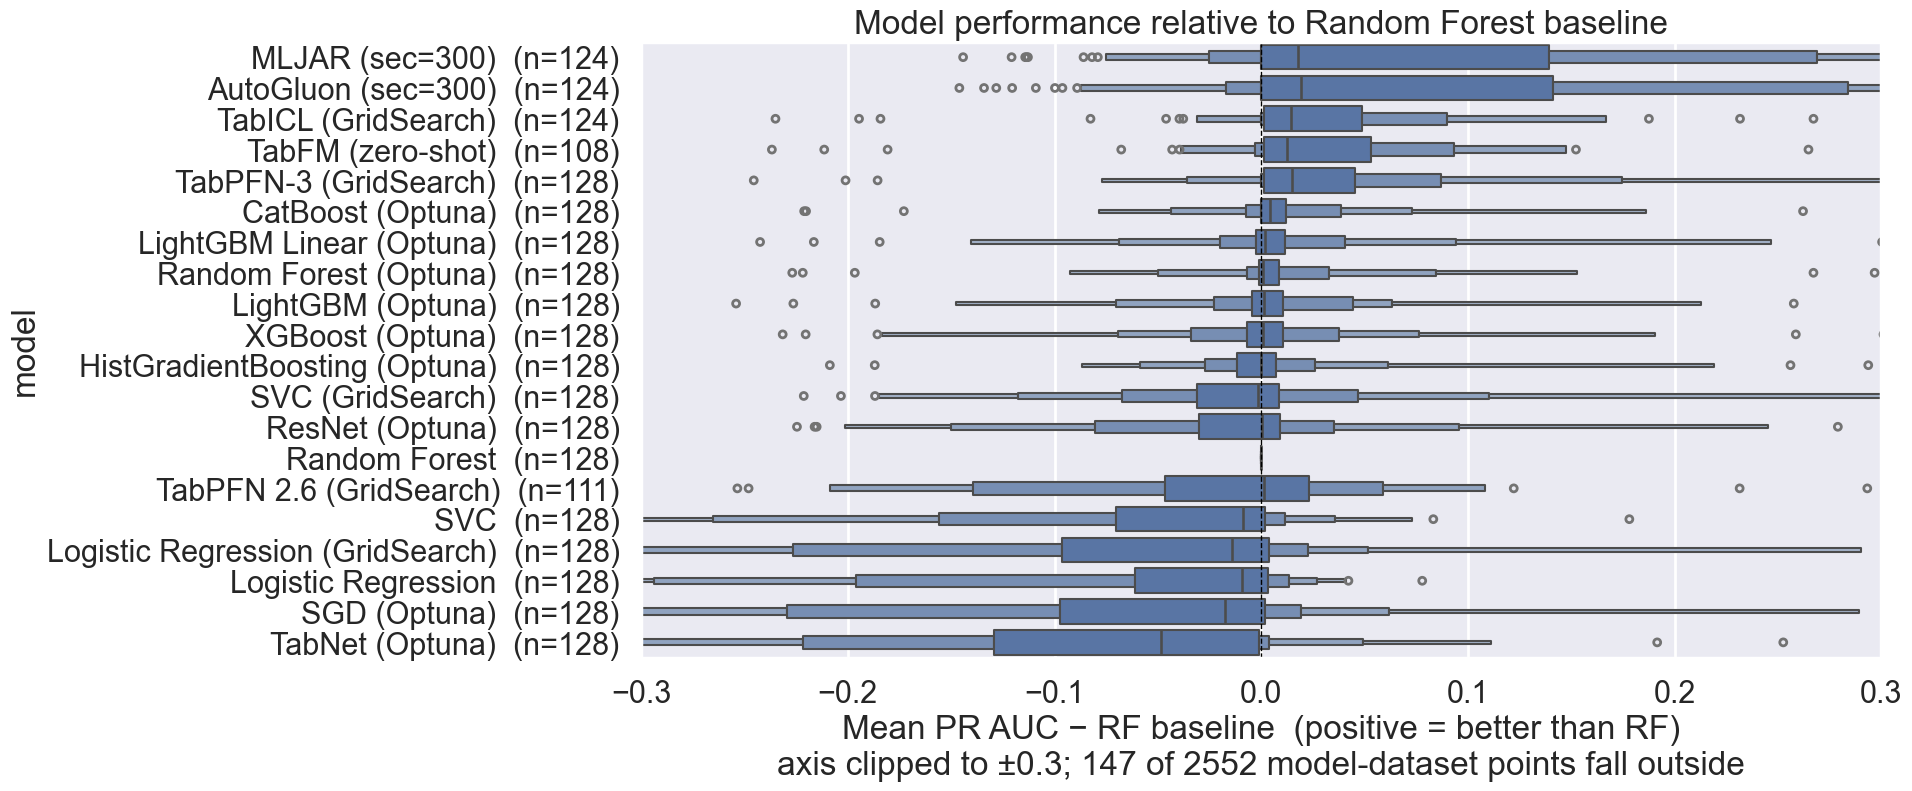

In [9]:
# distributions of delta PR AUC vs RF baseline.
# n is per-model coverage — the boxes are not drawn over the same datasets.
counts = results_df.groupby('model')['mean_delta'].count()
order = results_df.groupby('model')['mean_delta'].mean().sort_values(ascending=False).index
fig, ax = plt.subplots()
fig.set_size_inches(16, 8)
sns.boxenplot(data=results_df, x='mean_delta', y='model', order=order, ax=ax)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
# Clip the axis: a 4% tail would squeeze every box into an unreadable strip.
# What falls outside is annotated rather than hidden.
XLIM = 0.3
ax.set_xlim(-XLIM, XLIM)
n_out = (results_df['mean_delta'].abs() > XLIM).sum()
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f'{m}  (n={counts[m]})' for m in order])
ax.set_xlabel(f'Mean PR AUC − RF baseline  (positive = better than RF)'
              f'\naxis clipped to ±{XLIM}; {n_out} of {len(results_df)} '
              f'model-dataset points fall outside')
ax.set_title('Model performance relative to Random Forest baseline')

Text(127.16420654296876, 0.5, 'Mean PR AUC − RF baseline')

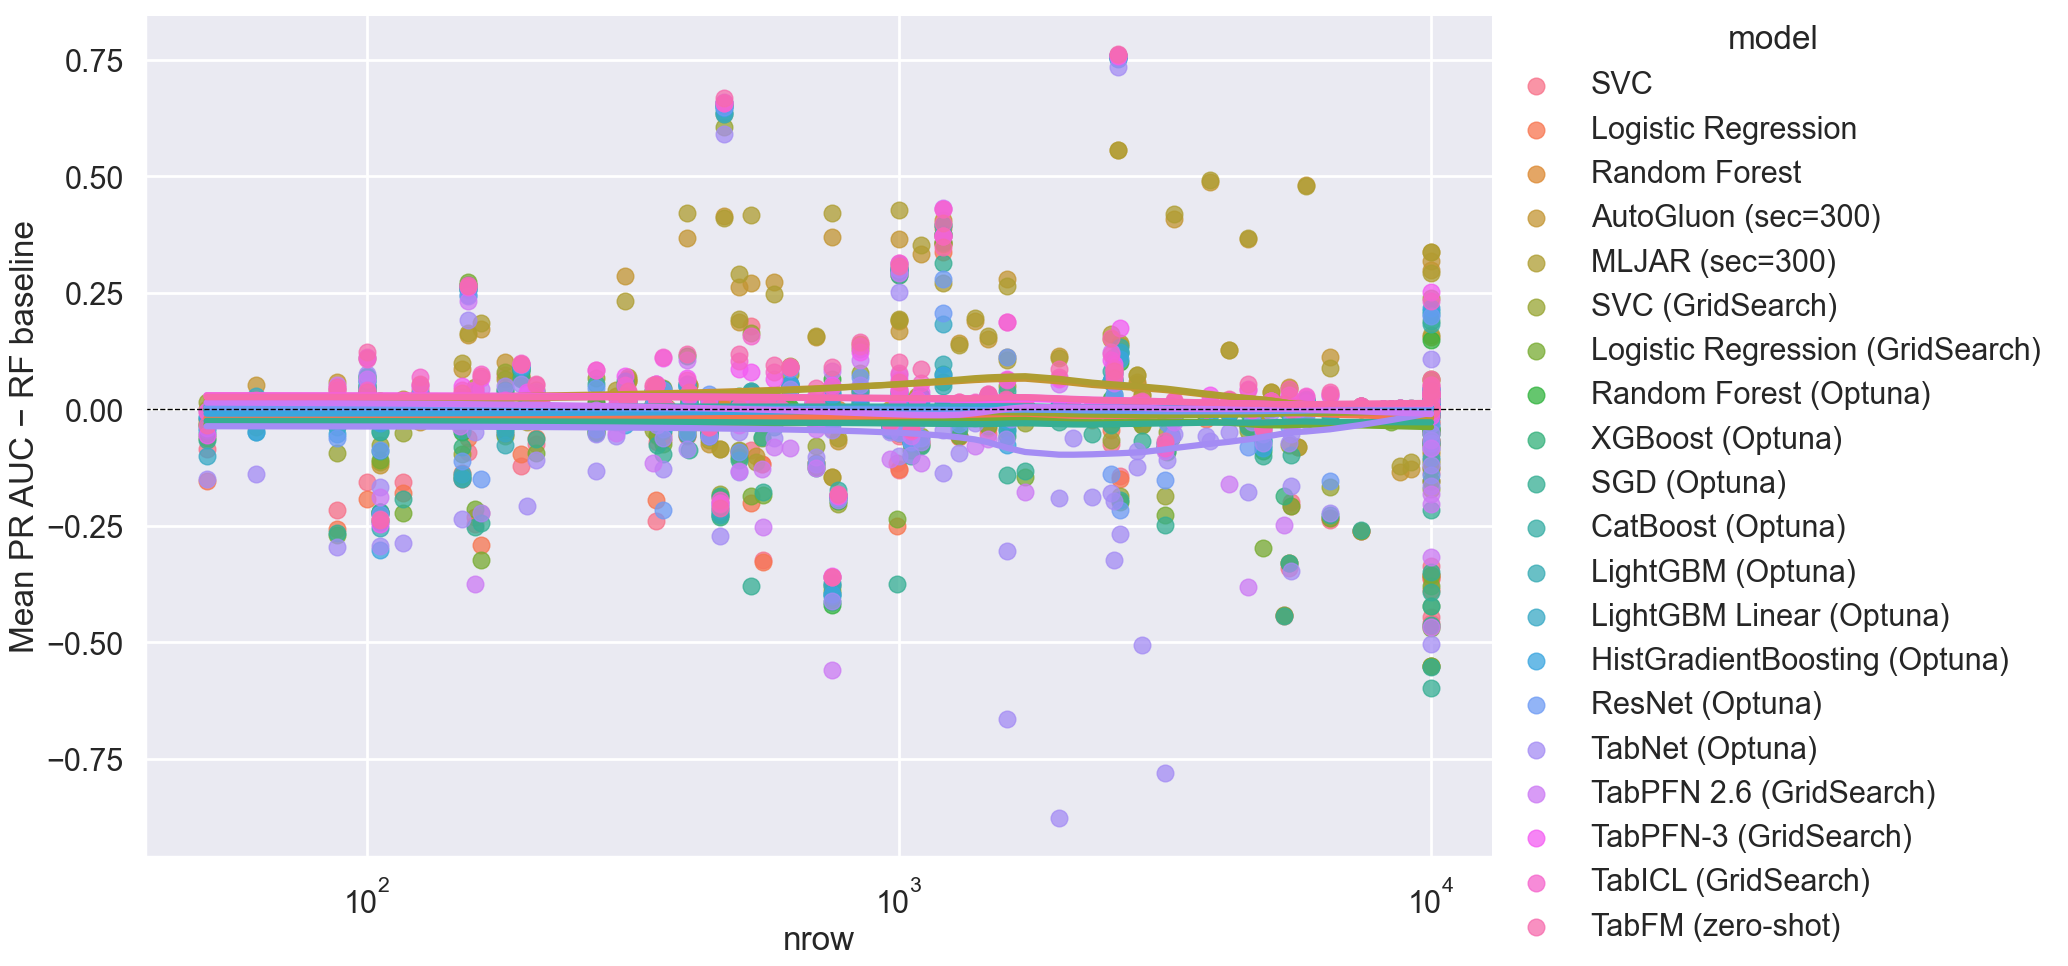

In [10]:
# delta PR AUC vs RF baseline vs number of samples in the data
g = sns.lmplot(
    data=results_df,
    x='nrow', y='mean_delta',
    hue='model',
    lowess=True,
    height=10,
    aspect=1.6,
    scatter_kws={'alpha': 0.75}
)
g.set(xscale='log')
g.ax.axhline(0, color='black', linestyle='--', linewidth=1)
g.ax.set_ylabel('Mean PR AUC − RF baseline')


Text(0.5, 1.0, 'Time vs performance')

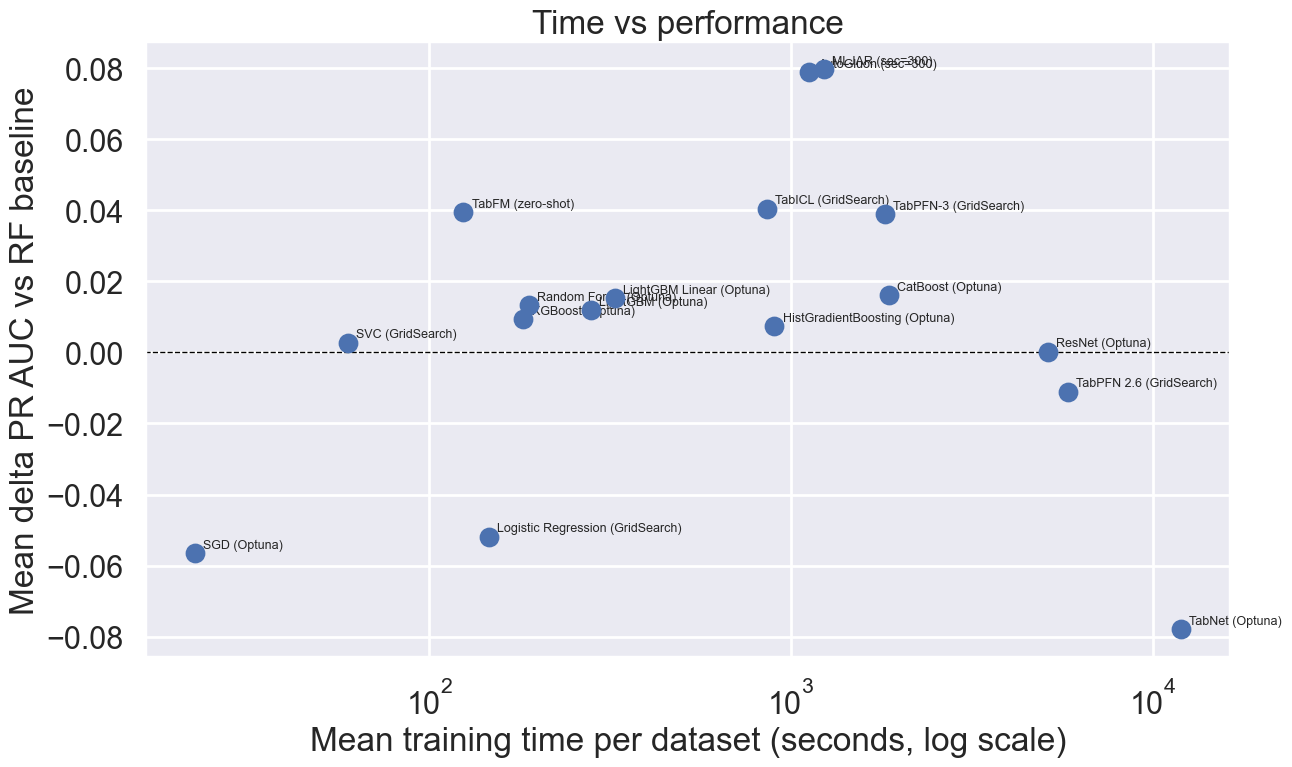

In [11]:
# Time-performance tradeoff
time_lookup = {}
for model_key, label in OPTUNA_MODEL_LABELS.items():
    if model_key in optuna_times and len(optuna_times[model_key]) > 0:
        time_lookup[label] = np.nanmean(optuna_times[model_key])
time_lookup['AutoGluon (sec=300)'] = np.nanmean(autogluon_times)
time_lookup['MLJAR (sec=300)'] = np.nanmean(mljar_times)

model_delta_mean = results_df.groupby('model')['mean_delta'].mean()
time_rows = []
for m, t in time_lookup.items():
    d = model_delta_mean.get(m, np.nan)
    time_rows.append({'model': m, 'mean_time_sec': t, 'mean_delta': d})
time_df = pd.DataFrame(time_rows).dropna()

fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(time_df['mean_time_sec'], time_df['mean_delta'], s=150, zorder=5)
for _, row in time_df.iterrows():
    ax.annotate(row['model'], (row['mean_time_sec'], row['mean_delta']),
                fontsize=9, xytext=(6, 4), textcoords='offset points')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Mean training time per dataset (seconds, log scale)')
ax.set_ylabel('Mean delta PR AUC vs RF baseline')
ax.set_title('Time vs performance')


Text(0.5, 1.0, 'Rank distribution across 106 datasets scored by all 20 models')

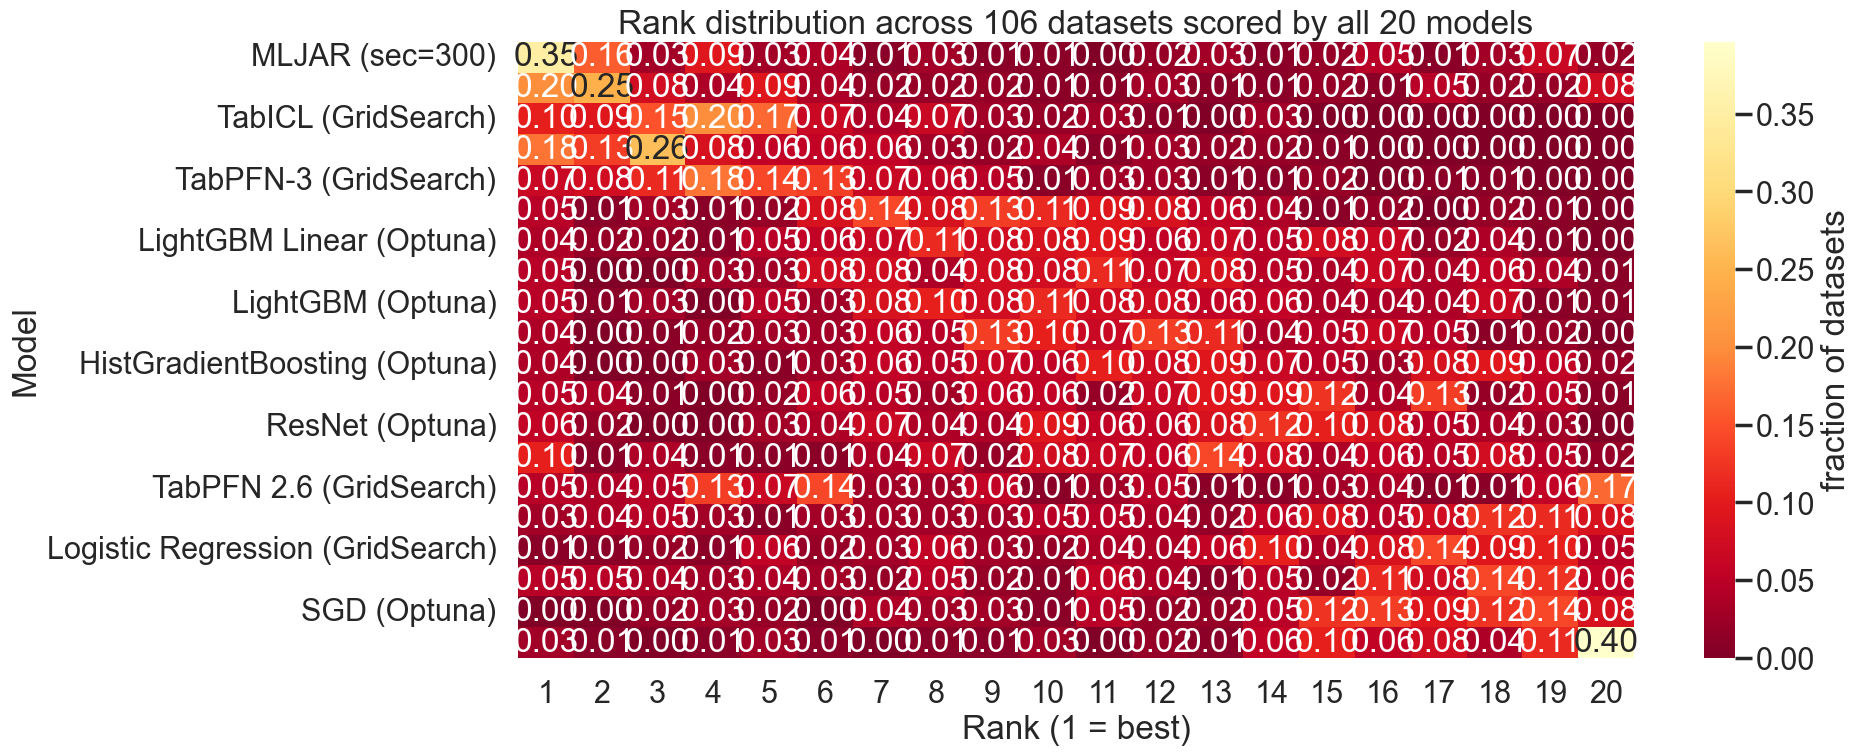

In [12]:
# Rank heatmap: fraction of datasets each model is rank k.
# Complete cases only: ranks compare only across identical datasets.
pivot_full = results_df.pivot_table(index='dataset', columns='model', values='mean_prauc').dropna()
models_by_rank = (results_df.groupby('model')['mean_delta'].mean()
                  .sort_values(ascending=False).index.tolist())
rank_pivot_full = pivot_full[models_by_rank].rank(axis=1, ascending=False, method='min')
n_ds = len(rank_pivot_full)

rank_frac = pd.DataFrame(index=models_by_rank)
for r in range(1, len(models_by_rank) + 1):
    rank_frac[r] = (rank_pivot_full == r).sum() / n_ds
assert np.allclose(rank_frac.sum(axis=1), 1.0), 'each row must be a distribution'

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(rank_frac, annot=True, fmt='.2f', cmap='YlOrRd_r', ax=ax,
            cbar_kws={'label': 'fraction of datasets'})
ax.set_xlabel('Rank (1 = best)')
ax.set_ylabel('Model')
ax.set_title(f'Rank distribution across {n_ds} datasets scored by all {len(models_by_rank)} models')

Friedman p = 9.89e-120 over 106 datasets, 17 models, 136 pairs


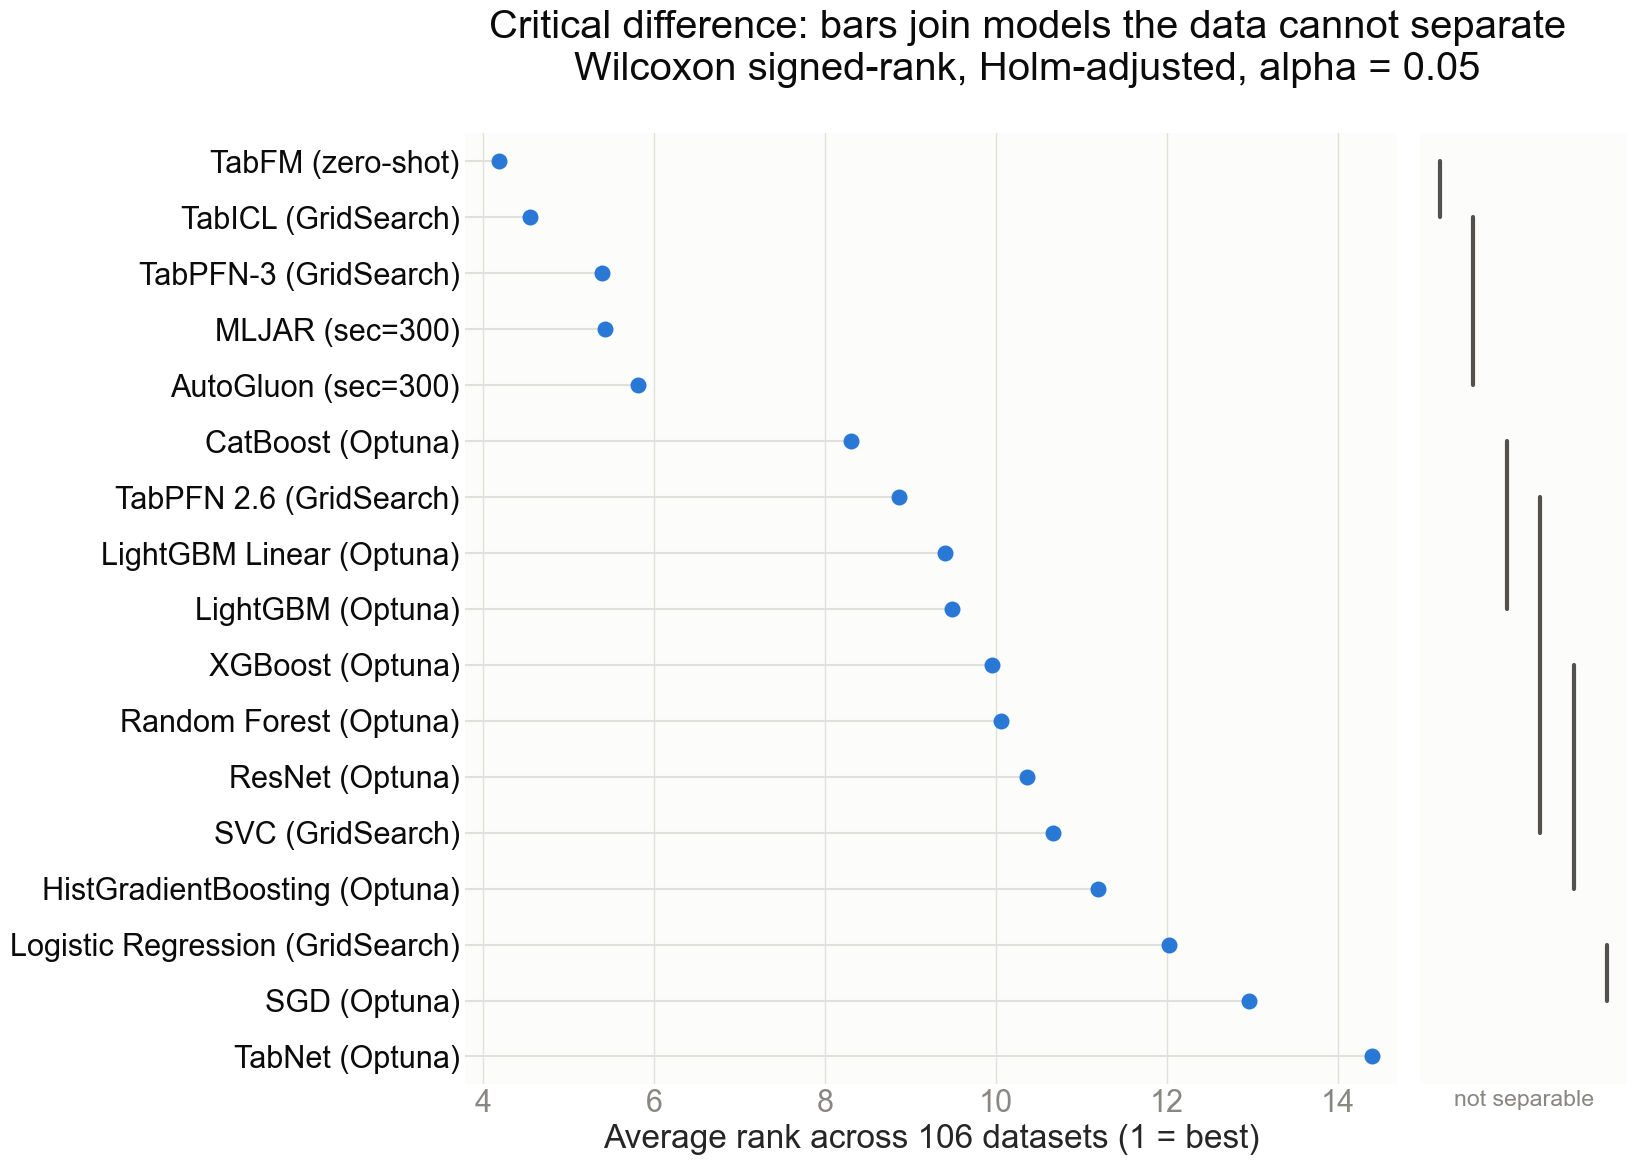

In [13]:
# Significance. The headline gaps are 0.002-0.009 wide, so a ranking alone does
# not say which of them the data supports. One dataset is one observation; the
# four folds of a dataset share their data and would inflate the sample.
#
# The three GridSearch baselines are the same learners as their tuned entries.
# Pairs between the two versions are not comparisons this report makes, and
# carrying them would widen the Holm family from 136 pairs to 190.
ALPHA = 0.05
BASELINE_DUPLICATES = ['SVC', 'Logistic Regression', 'Random Forest']
tested = pivot_full.drop(columns=BASELINE_DUPLICATES)

ranks = average_ranks(tested)
adjusted = wilcoxon_holm(tested)
groups = cliques(ranks, adjusted, ALPHA)
print(f'Friedman p = {friedman_p(tested):.3g} over {len(tested)} datasets, '
      f'{len(tested.columns)} models, {len(adjusted) // 2} pairs')

fig = critical_difference_diagram(ranks, groups, len(tested), ALPHA)
fig.savefig('figures/critical_difference.png', dpi=150, bbox_inches='tight')

In [14]:
# The pairs the README stands on. The raw column shows what the correction for
# 136 comparisons is doing to each verdict.
HEADLINE_PAIRS = [
    ('MLJAR (sec=300)', 'TabFM (zero-shot)'),
    ('MLJAR (sec=300)', 'CatBoost (Optuna)'),
    ('TabFM (zero-shot)', 'TabPFN-3 (GridSearch)'),
    ('TabFM (zero-shot)', 'CatBoost (Optuna)'),
    ('CatBoost (Optuna)', 'LightGBM Linear (Optuna)'),
    ('CatBoost (Optuna)', 'Random Forest (Optuna)'),
    ('CatBoost (Optuna)', 'HistGradientBoosting (Optuna)'),
]
for a, b in HEADLINE_PAIRS:
    p = adjusted.loc[(a, b)]
    diff = tested[a] - tested[b]
    verdict = 'separable' if p['holm'] < ALPHA else 'NOT separable'
    print(f'{a:32s} vs {b:32s} mean {diff.mean():+.4f}  '
          f'wins {(diff > 0).sum():3d}/{len(diff)}  raw p={p["raw"]:.4g}  '
          f'Holm p={p["holm"]:.4g}  {verdict}')

MLJAR (sec=300)                  vs TabFM (zero-shot)                mean +0.0295  wins  61/106  raw p=0.01491  Holm p=0.4324  NOT separable
MLJAR (sec=300)                  vs CatBoost (Optuna)                mean +0.0547  wins  76/106  raw p=2.017e-05  Holm p=0.001029  separable
TabFM (zero-shot)                vs TabPFN-3 (GridSearch)            mean +0.0041  wins  73/106  raw p=8.124e-05  Holm p=0.003818  separable
TabFM (zero-shot)                vs CatBoost (Optuna)                mean +0.0252  wins  89/106  raw p=4.558e-12  Holm p=4.421e-10  separable
CatBoost (Optuna)                vs LightGBM Linear (Optuna)         mean -0.0006  wins  60/106  raw p=0.08065  Holm p=1  NOT separable
CatBoost (Optuna)                vs Random Forest (Optuna)           mean +0.0021  wins  70/106  raw p=0.0008878  Holm p=0.03729  separable
CatBoost (Optuna)                vs HistGradientBoosting (Optuna)    mean +0.0067  wins  75/106  raw p=4.375e-06  Holm p=0.0002669  separable


In [15]:
# Calibration. PR AUC scores ranking only: a model can order every case
# correctly and still be systematically overconfident. Brier and ECE read the
# probabilities themselves, from the same stored out-of-fold predictions.
# AutoGluon and MLJAR stored scores and times only, so they cannot appear here.
FOUNDATION = {OPTUNA_MODEL_LABELS[k] for k in ('tabfm', 'tabicl', 'tabpfn3', 'tabpfn')}


def calibration_table(exclude=frozenset()):
    """Per-model means over the datasets every included model scores.

    Checkpoints are read one model at a time: all fifteen at once is ~470 MB of
    predictions for work that touches one of them at a time.
    """
    rows = []
    for model_key in available_models():
        if model_key in exclude:
            continue
        for dataset, entry in joblib.load(ckpt_path(model_key)).items():
            if entry.get('preds') is None or dataset not in evaluated_datasets:
                continue
            prob = np.vstack(entry['preds'])
            y = np.concatenate(entry['labels'])
            rows.append({'model': OPTUNA_MODEL_LABELS[model_key], 'dataset': dataset,
                         'prauc': np.mean(entry['scores']),
                         'brier': brier_score(y, prob),
                         'ece': expected_calibration_error(y, prob)})

    wide = pd.DataFrame(rows).pivot_table(index='dataset', columns='model',
                                          values=['prauc', 'brier', 'ece'])
    complete = wide['ece'].dropna().index
    table = pd.DataFrame({'PR AUC': wide['prauc'].loc[complete].mean(),
                          'Brier': wide['brier'].loc[complete].mean(),
                          'ECE': wide['ece'].loc[complete].mean()}).sort_values('ECE')
    return table, complete


calib_df, complete = calibration_table(exclude={'tabpfn'})
print(f'{len(complete)} datasets scored by all {len(calib_df)} models')
print(calib_df.round(4).to_string())

# TabPFN 2.6 kept predictions for 80 datasets, so requiring them shrinks the
# comparison sharply. Findings_notes.md cites how the ordering moves.
with_tabpfn, complete_26 = calibration_table()
print(f'\nwith TabPFN 2.6: {len(complete_26)} datasets')
print(with_tabpfn.round(4).to_string())

108 datasets scored by all 14 models
                                  PR AUC   Brier     ECE
model                                                   
TabFM (zero-shot)                 0.8596  0.1881  0.0367
TabICL (GridSearch)               0.8574  0.1905  0.0405
TabPFN-3 (GridSearch)             0.8557  0.2127  0.0443
SVC (GridSearch)                  0.8240  0.2350  0.0477
ResNet (Optuna)                   0.8211  0.2446  0.0512
XGBoost (Optuna)                  0.8294  0.2394  0.0627
LightGBM (Optuna)                 0.8311  0.2443  0.0674
Logistic Regression (GridSearch)  0.7838  0.3084  0.0732
HistGradientBoosting (Optuna)     0.8274  0.2526  0.0739
Random Forest (Optuna)            0.8325  0.2410  0.0747
LightGBM Linear (Optuna)          0.8348  0.2457  0.0756
CatBoost (Optuna)                 0.8342  0.2496  0.0848
TabNet (Optuna)                   0.7529  0.3238  0.0851
SGD (Optuna)                      0.7837  0.3254  0.1000



with TabPFN 2.6: 62 datasets
                                  PR AUC   Brier     ECE
model                                                   
TabFM (zero-shot)                 0.8989  0.1380  0.0276
TabICL (GridSearch)               0.8981  0.1380  0.0304
TabPFN 2.6 (GridSearch)           0.8953  0.1621  0.0351
TabPFN-3 (GridSearch)             0.8980  0.1586  0.0370
SVC (GridSearch)                  0.8699  0.1839  0.0401
ResNet (Optuna)                   0.8643  0.1939  0.0413
XGBoost (Optuna)                  0.8703  0.1881  0.0505
Logistic Regression (GridSearch)  0.8366  0.2369  0.0548
LightGBM (Optuna)                 0.8696  0.1978  0.0637
LightGBM Linear (Optuna)          0.8766  0.1910  0.0639
HistGradientBoosting (Optuna)     0.8679  0.2013  0.0673
Random Forest (Optuna)            0.8694  0.1943  0.0698
CatBoost (Optuna)                 0.8723  0.1984  0.0750
TabNet (Optuna)                   0.7782  0.2834  0.0759
SGD (Optuna)                      0.8372  0.2610  0.0967


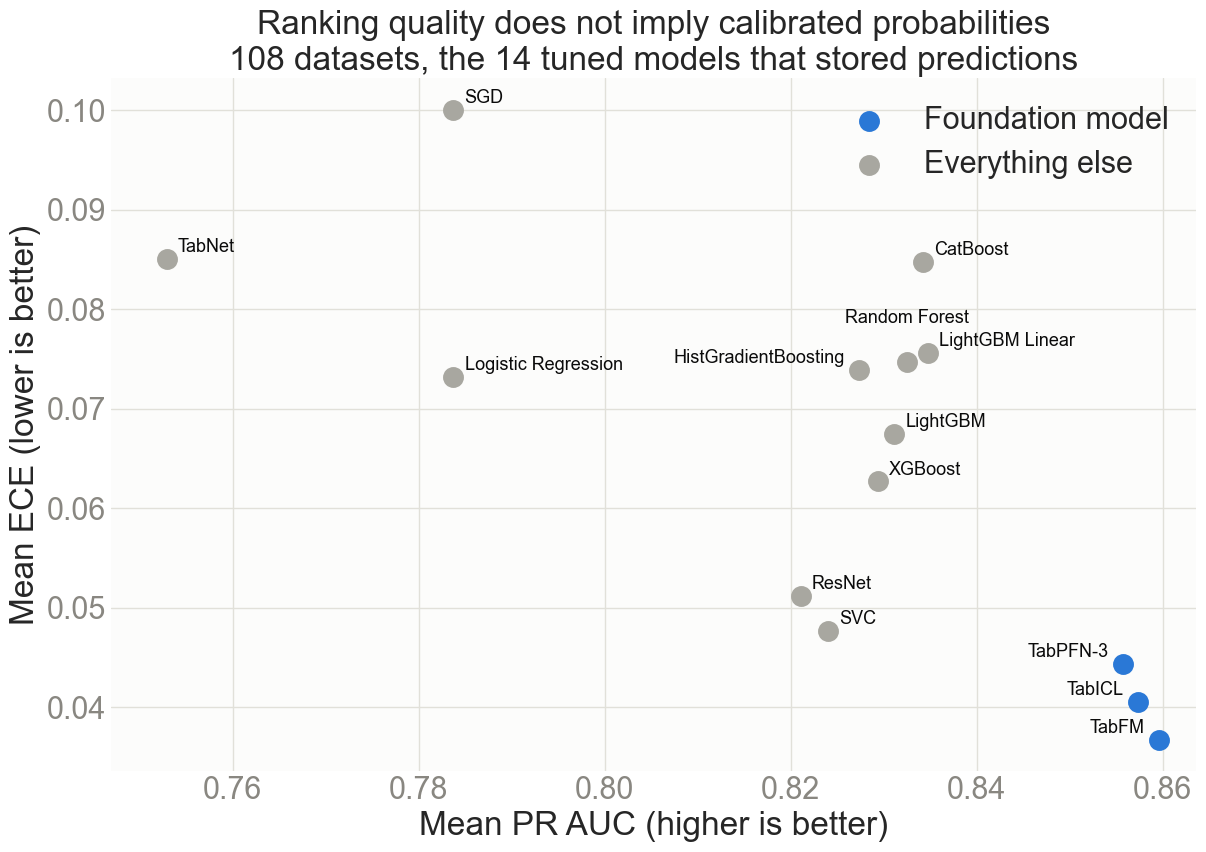

In [16]:
fig, ax = plt.subplots(figsize=(14, 9))
for label, colour, models in [
    ('Foundation model', ACCENT, [m for m in calib_df.index if m in FOUNDATION]),
    ('Everything else', CONTEXT, [m for m in calib_df.index if m not in FOUNDATION]),
]:
    ax.scatter(calib_df.loc[models, 'PR AUC'], calib_df.loc[models, 'ECE'],
               s=170, color=colour, label=label, zorder=3)

# The foundation cluster would run off the right edge and three boosted entries
# land within 0.002 of each other. Every model here comes from the same tuned
# pipeline, so the tuner suffix only adds width to a label that already collides.
RIGHT, LEFT = ((-10, 5), 'right'), ((8, 5), 'left')
PLACEMENT = {'Random Forest (Optuna)': ((0, 28), 'center'),
             'HistGradientBoosting (Optuna)': RIGHT}
x_max = calib_df['PR AUC'].max()
for model, row in calib_df.iterrows():
    offset, align = PLACEMENT.get(model, RIGHT if row['PR AUC'] > x_max - 0.01 else LEFT)
    ax.annotate(model.split(' (')[0], (row['PR AUC'], row['ECE']), fontsize=13,
                color=INK, textcoords='offset points', xytext=offset, ha=align)

ax.set_xlim(calib_df['PR AUC'].min() - 0.006, x_max + 0.004)
ax.set_xlabel('Mean PR AUC (higher is better)')
ax.set_ylabel('Mean ECE (lower is better)')
ax.set_title('Ranking quality does not imply calibrated probabilities\n'
             f'{len(complete)} datasets, the {len(calib_df)} tuned models that stored predictions')
ax.legend(frameon=False)
style_axes(ax)
fig.savefig('figures/calibration.png', dpi=150, bbox_inches='tight')

Text(120.9530932617187, 0.5, 'Std of delta PR AUC across folds')

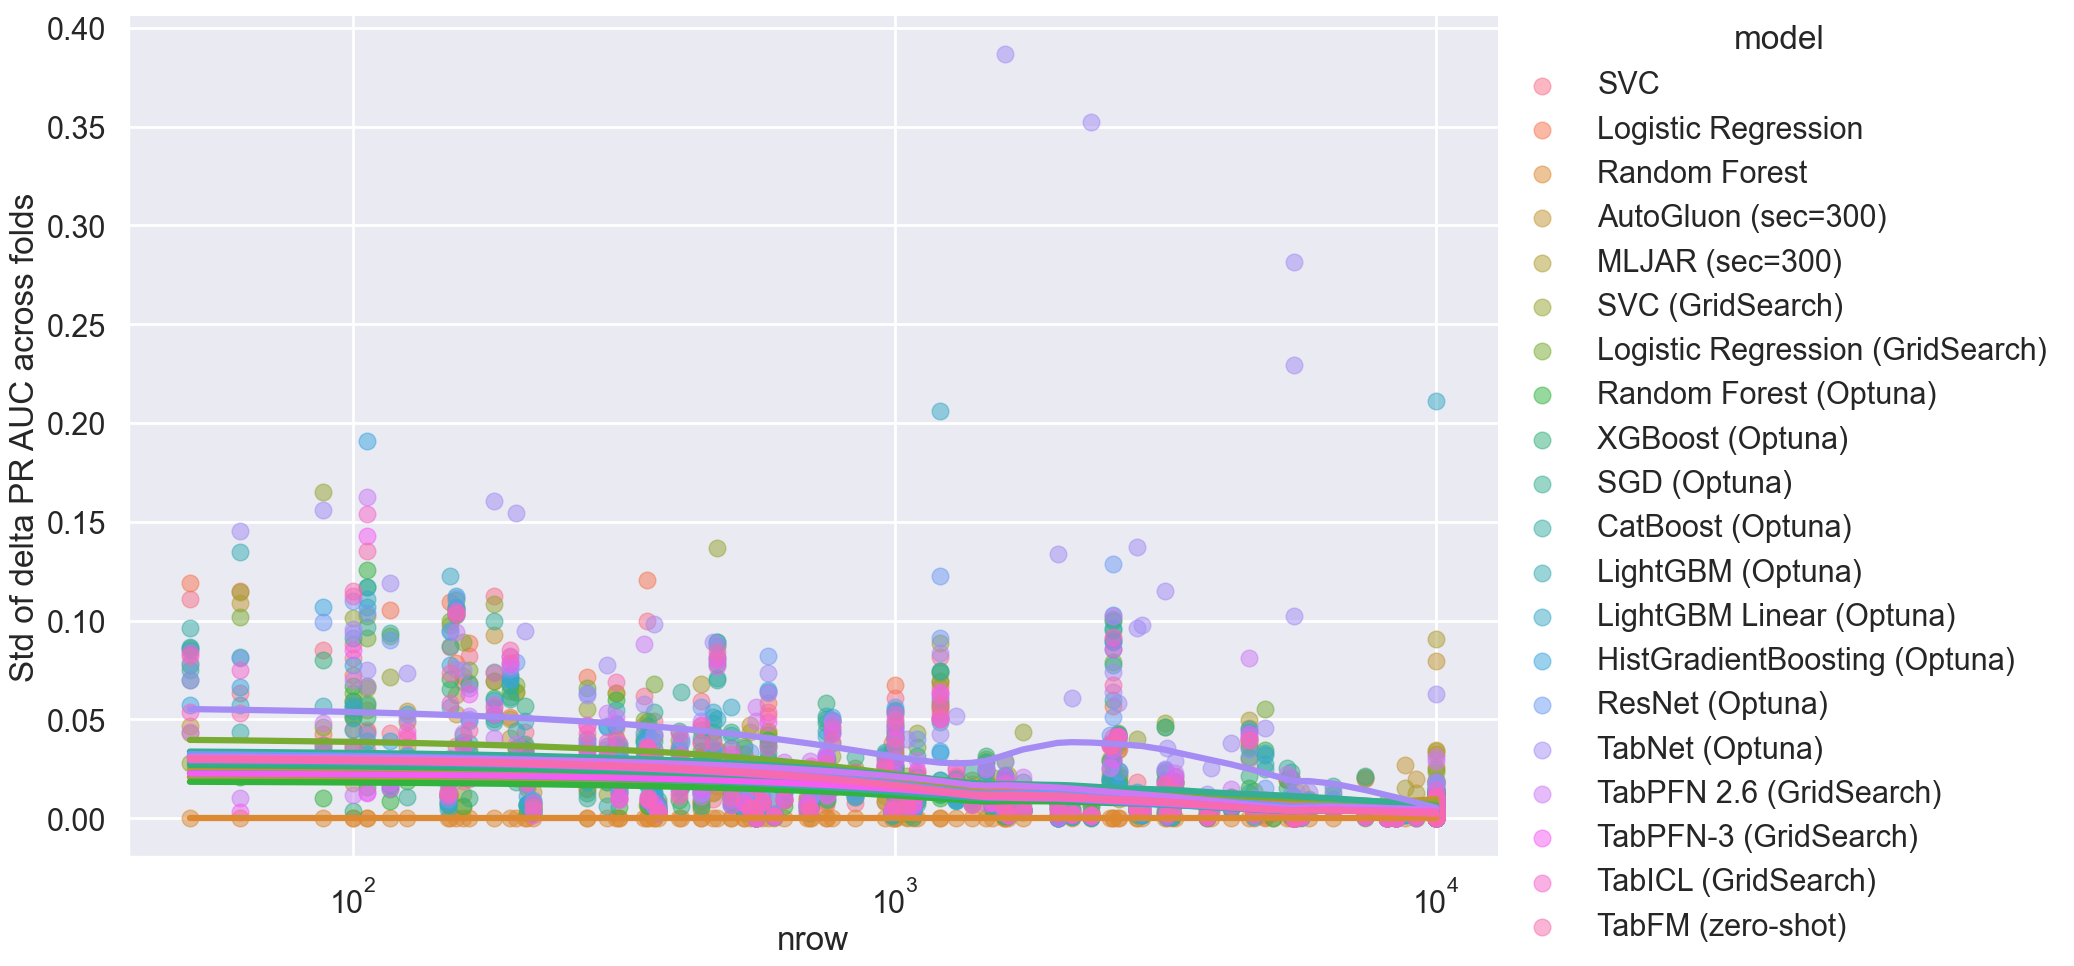

In [17]:
# variability of delta (across folds) vs number of samples
g = sns.lmplot(
    data=results_df,
    x='nrow', y='std_delta',
    hue='model',
    lowess=True,
    height=10,
    aspect=1.6,
    scatter_kws={'alpha': 0.5}
)
g.set(xscale='log')
g.ax.set_ylabel('Std of delta PR AUC across folds')


Text(127.16420654296876, 0.5, 'Mean delta PR AUC vs RF baseline')

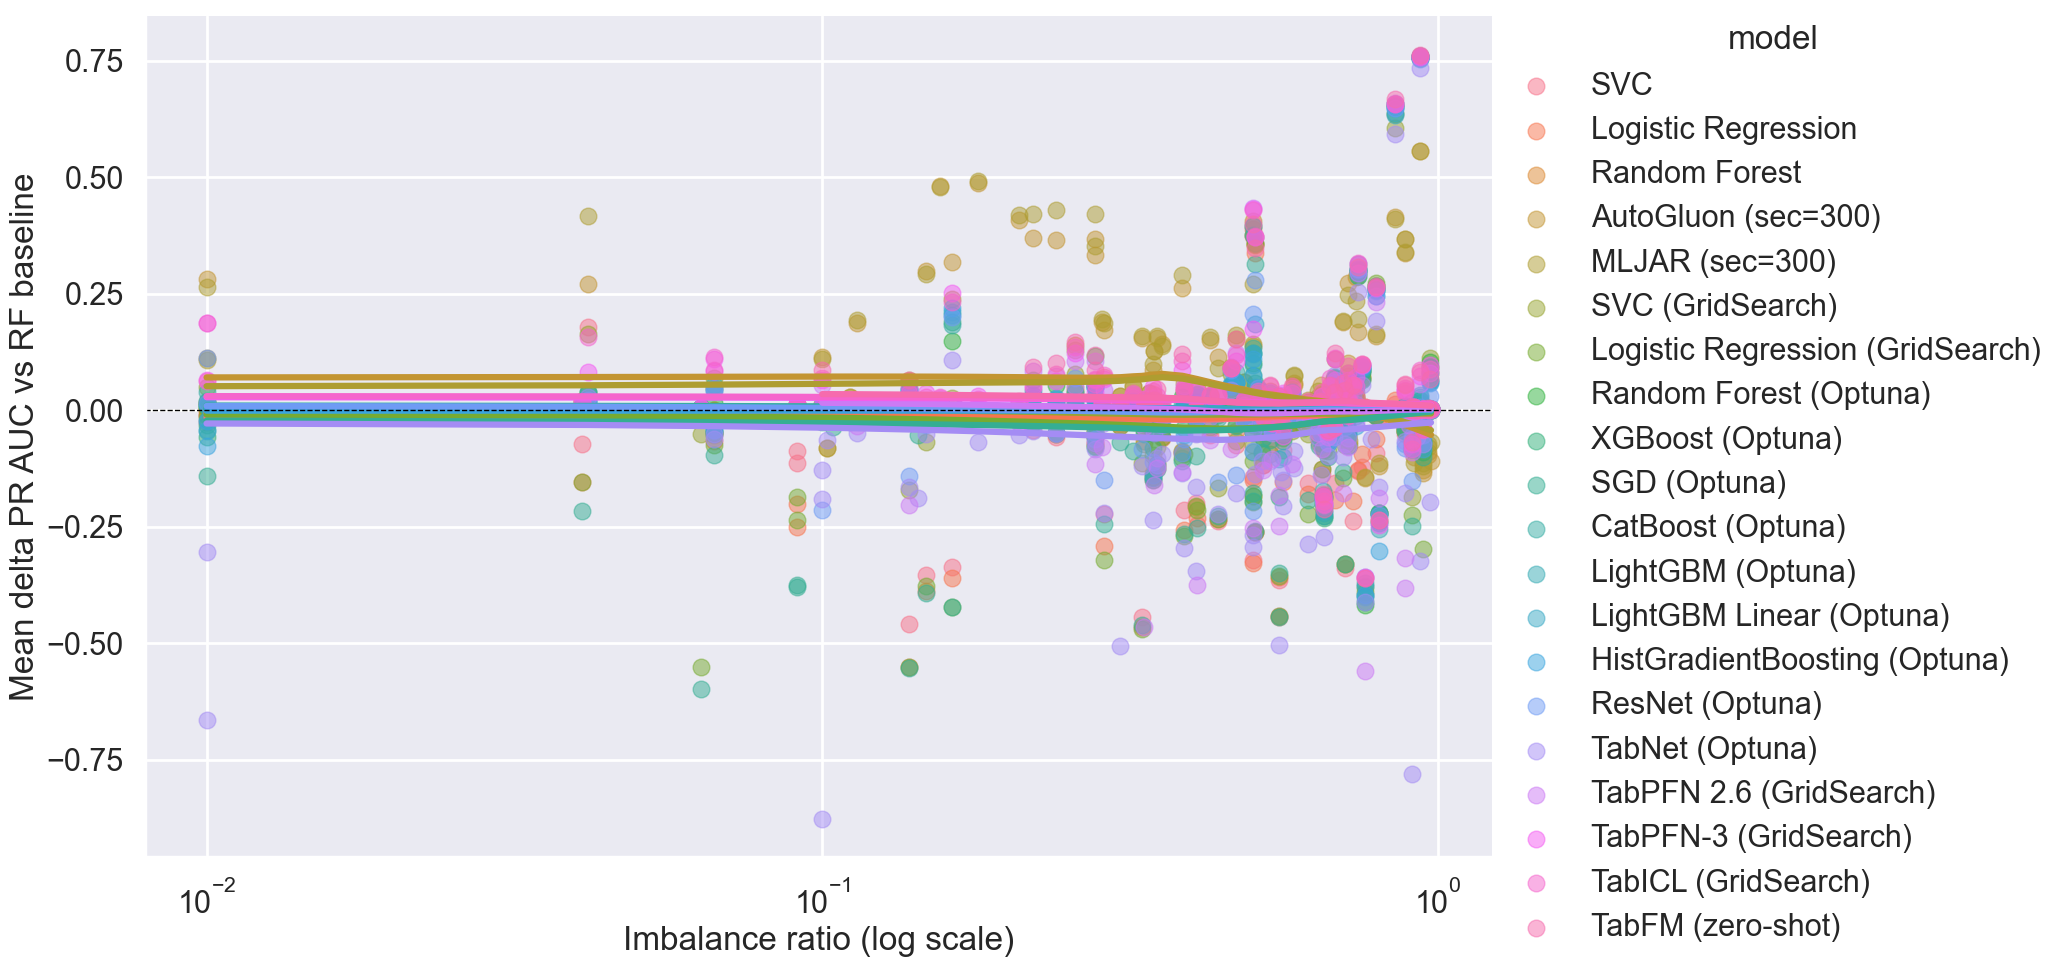

In [18]:
# delta PR AUC vs imbalance ratio
g = sns.lmplot(
    data=results_df,
    x='ir', y='mean_delta',
    hue='model',
    lowess=True,
    height=10,
    aspect=1.6,
    scatter_kws={'alpha': 0.5}
)
g.set(xscale='log')
g.ax.axhline(0, color='black', linestyle='--', linewidth=1)
g.ax.set_xlabel('Imbalance ratio (log scale)')
g.ax.set_ylabel('Mean delta PR AUC vs RF baseline')


Text(127.16420654296876, 0.5, 'Mean delta PR AUC vs RF baseline')

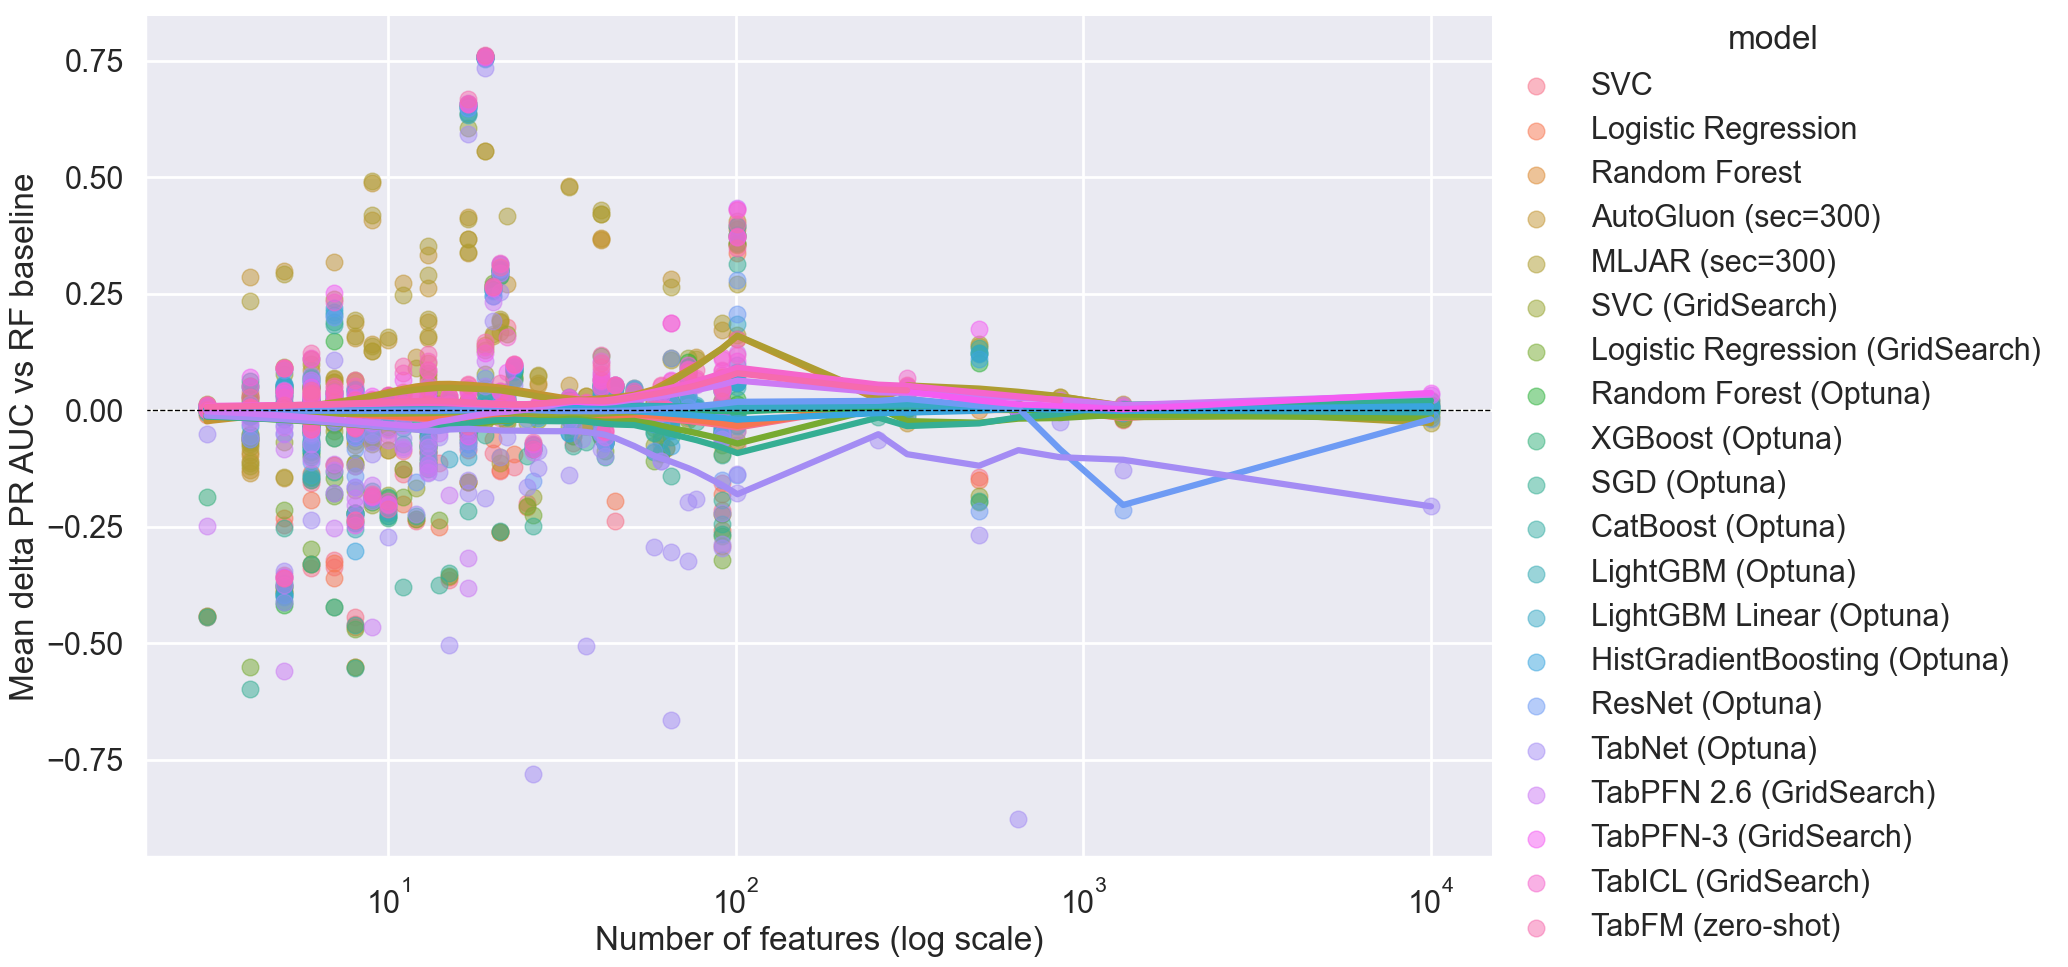

In [19]:
# delta PR AUC vs number of features
g = sns.lmplot(
    data=results_df,
    x='ncol', y='mean_delta',
    hue='model',
    lowess=True,
    height=10,
    aspect=1.6,
    scatter_kws={'alpha': 0.5}
)
g.set(xscale='log')
g.ax.axhline(0, color='black', linestyle='--', linewidth=1)
g.ax.set_xlabel('Number of features (log scale)')
g.ax.set_ylabel('Mean delta PR AUC vs RF baseline')


In [20]:
# datasets with the biggest gap between the best and second-best model.
# dropna() first: np.sort puts NaN last, so an unscored model would fill the
# printed tail with NaN.
def top2_gap(x):
    top2 = x.dropna().nlargest(2)
    return top2.iloc[0] - top2.iloc[1] if len(top2) == 2 else np.nan

results_df.groupby('dataset')['mean_prauc'].apply(top2_gap).nlargest(10)

dataset
meta-data                             0.146657
kr-vs-k                               0.067412
autoUniv-au6-1000                     0.062350
autoUniv-au6-cd1-400                  0.053499
habermans-survival                    0.052916
autoUniv-au6-250-drift-au6-cd1-500    0.050944
madelon                               0.031416
autoUniv-au7-cpd1-500                 0.026835
indian-liver-patient                  0.025836
colon32                               0.024474
Name: mean_prauc, dtype: float64